In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
libri_lengths = load_dataset("mariannedhk/librispeech_lengths")
train_lengths_df = pd.DataFrame(libri_lengths['train'])
train_wordcounts_df = pd.read_csv('librispeech_train_wordcounts.csv')

In [3]:
def print_stats(column, colwidth=10):
    print('TOTAL:'.ljust(colwidth), round(column.sum(), 2))
    print('MIN:'.ljust(colwidth), round(column.min(), 2))
    print('MAX:'.ljust(colwidth), round(column.max(), 2))
    print('MEAN:'.ljust(colwidth), round(column.mean(), 2))
    print('MEDIAN:'.ljust(colwidth), round(column.median(), 2))

In [4]:
print('Recording durations (seconds)')
print_stats(train_lengths_df['audio_duration'])

Recording durations (seconds)
TOTAL:     3459795.83
MIN:       0.83
MAX:       29.74
MEAN:      12.3
MEDIAN:    13.79


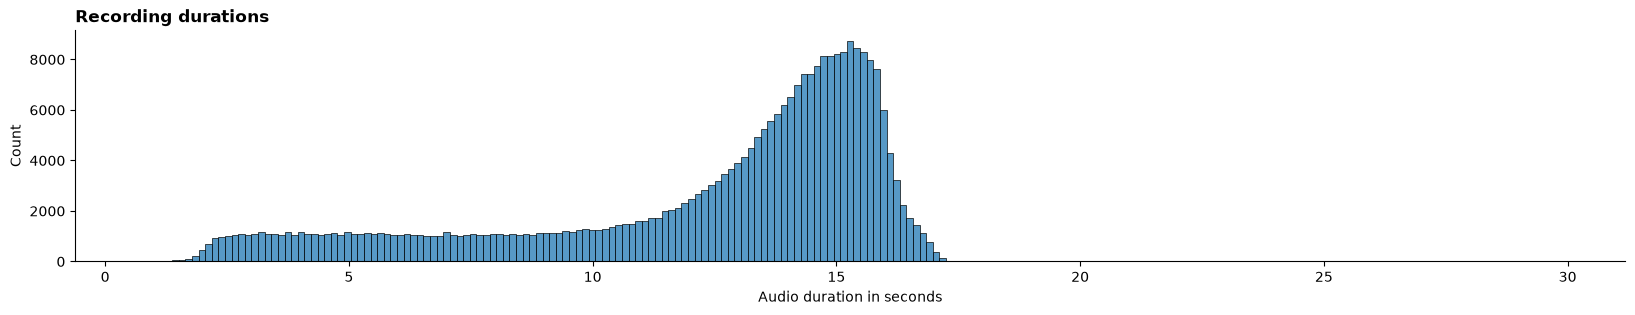

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(20,3))
sns.histplot(
    train_lengths_df, 
    x='audio_duration',
    ax=ax
)
ax.set_title('Recording durations', loc='left', weight='bold')
ax.set_xlabel('Audio duration in seconds')
sns.despine()
plt.show()

In [6]:
print('Number of words')
print_stats(train_lengths_df['word_count'])

Number of words
TOTAL:     9403555
MIN:       1
MAX:       87
MEAN:      33.44
MEDIAN:    35.0


In [7]:
print('Number of unique words:', len(train_wordcounts_df))

Number of unique words: 89114


In [8]:
print('Number of speakers:', len(train_lengths_df['speaker_id'].unique()))

Number of speakers: 2338


In [9]:
speaker_durations = train_lengths_df.groupby('speaker_id', as_index=False
).agg({'audio_duration': 'sum'}
).sort_values(by='audio_duration', ascending=False
).reset_index(drop=True
)
speaker_durations['audio_duration_minutes'] = speaker_durations['audio_duration'].apply(lambda x: round(x/60, 2))
speaker_durations

,speaker_id,audio_duration,audio_duration_minutes
0,6512,1815.865000,30.26
1,2967,1815.684937,30.26
2,252,1815.430000,30.26
3,3656,1815.310000,30.26
4,2997,1815.304938,30.26
...,...,...,...
2333,5217,255.135000,4.25
2334,3138,211.955000,3.53
2335,3381,179.299937,2.99
2336,1645,115.420000,1.92


In [10]:
speaker_word_counts = train_lengths_df.groupby('speaker_id', as_index=False
).agg({'word_count': 'sum'}
).sort_values(by='word_count', ascending=False
).reset_index(drop=True
)
speaker_word_counts

,speaker_id,word_count
0,7391,6546
1,3196,6428
2,7265,6234
3,614,6164
4,8625,6134
...,...,...
2333,2146,749
2334,3138,562
2335,3381,432
2336,7909,349


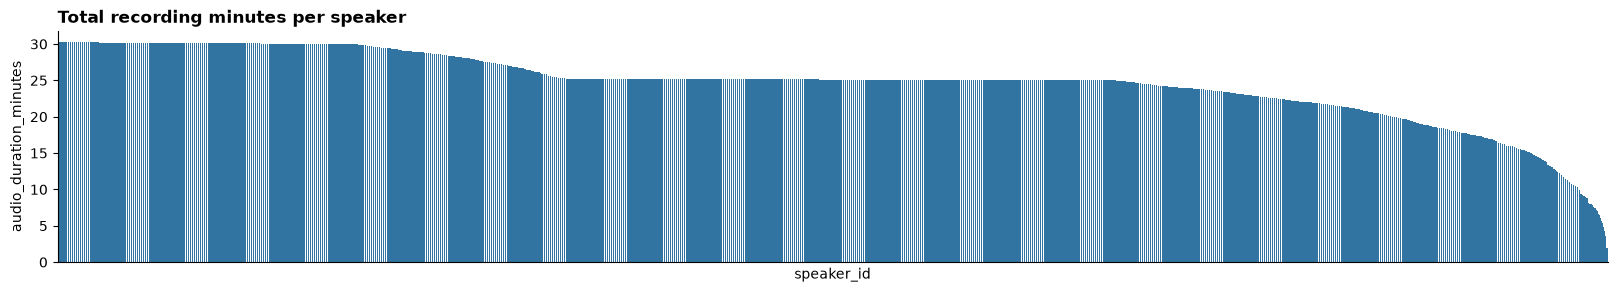

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(20,3))
sns.barplot(
    speaker_durations, 
    x='speaker_id', 
    y='audio_duration_minutes', 
    order=speaker_durations['speaker_id'].values, 
    ax=ax
)
ax.set_xticks([])
ax.set_title('Total recording minutes per speaker', loc='left', weight='bold')
sns.despine()
plt.show()

In [12]:
round(len(speaker_durations[speaker_durations['audio_duration_minutes'] > 20])/len(speaker_durations),2)

0.86

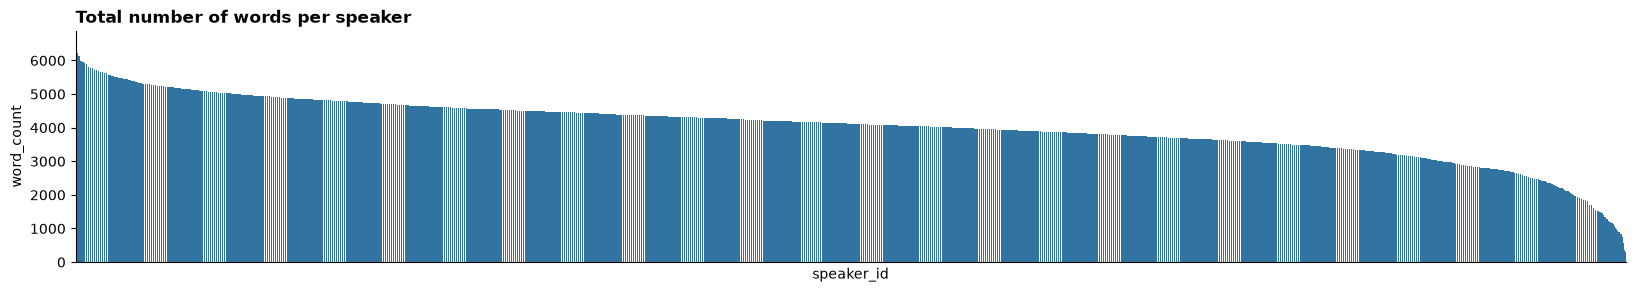

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(20,3))
sns.barplot(
    speaker_word_counts, 
    x='speaker_id', 
    y='word_count', 
    order=speaker_word_counts['speaker_id'].values, 
    ax=ax
)
ax.set_xticks([])
ax.set_title('Total number of words per speaker', loc='left', weight='bold')
sns.despine()
plt.show()

In [14]:
round(len(speaker_word_counts[speaker_word_counts['word_count'] > 3000])/len(speaker_word_counts),2)

0.88